#Recolección de datos

Se importan los datos desde Kaggle. Se ocupa el código
que sugiere la plataforma para siempre tener los últimos datos disponibles

Fabio Mendoza Palechor, and ,Alexis de la Hoz Manotas. (2023). Obesity or CVD risk (Classify/Regressor/Cluster) [Dataset]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/7009925

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "ObesityDataSet.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_706/2590714379.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'obesity-or-cvd-risk-classifyregressorcluster' dataset.
First 5 records:    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Tr

EDA

Realizamos un pequeño analisis exploratorio para comprender mejor los datos


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

The attributes related with eating habits are: Frequent consumption of high caloric food (FAVC), Frequency of consumption of vegetables (FCVC), Number of main meals (NCP), Consumption of food between meals (CAEC), Consumption of water daily (CH20), and Consumption of alcohol (CALC). The attributes related with the physical condition are: Calories consumption monitoring (SCC), Physical activity frequency (FAF), Time using technology devices (TUE), Transportation used (MTRANS) variables obtained : Gender, Age, Height and Weight.

NObesity values are:

•Underweight Less than 18.5 •Normal 18.5 to 24.9 •Overweight 25.0 to 29.9 •Obesity I 30.0 to 34.9 •Obesity II 35.0 to 39.9 •Obesity III Higher than 40

In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


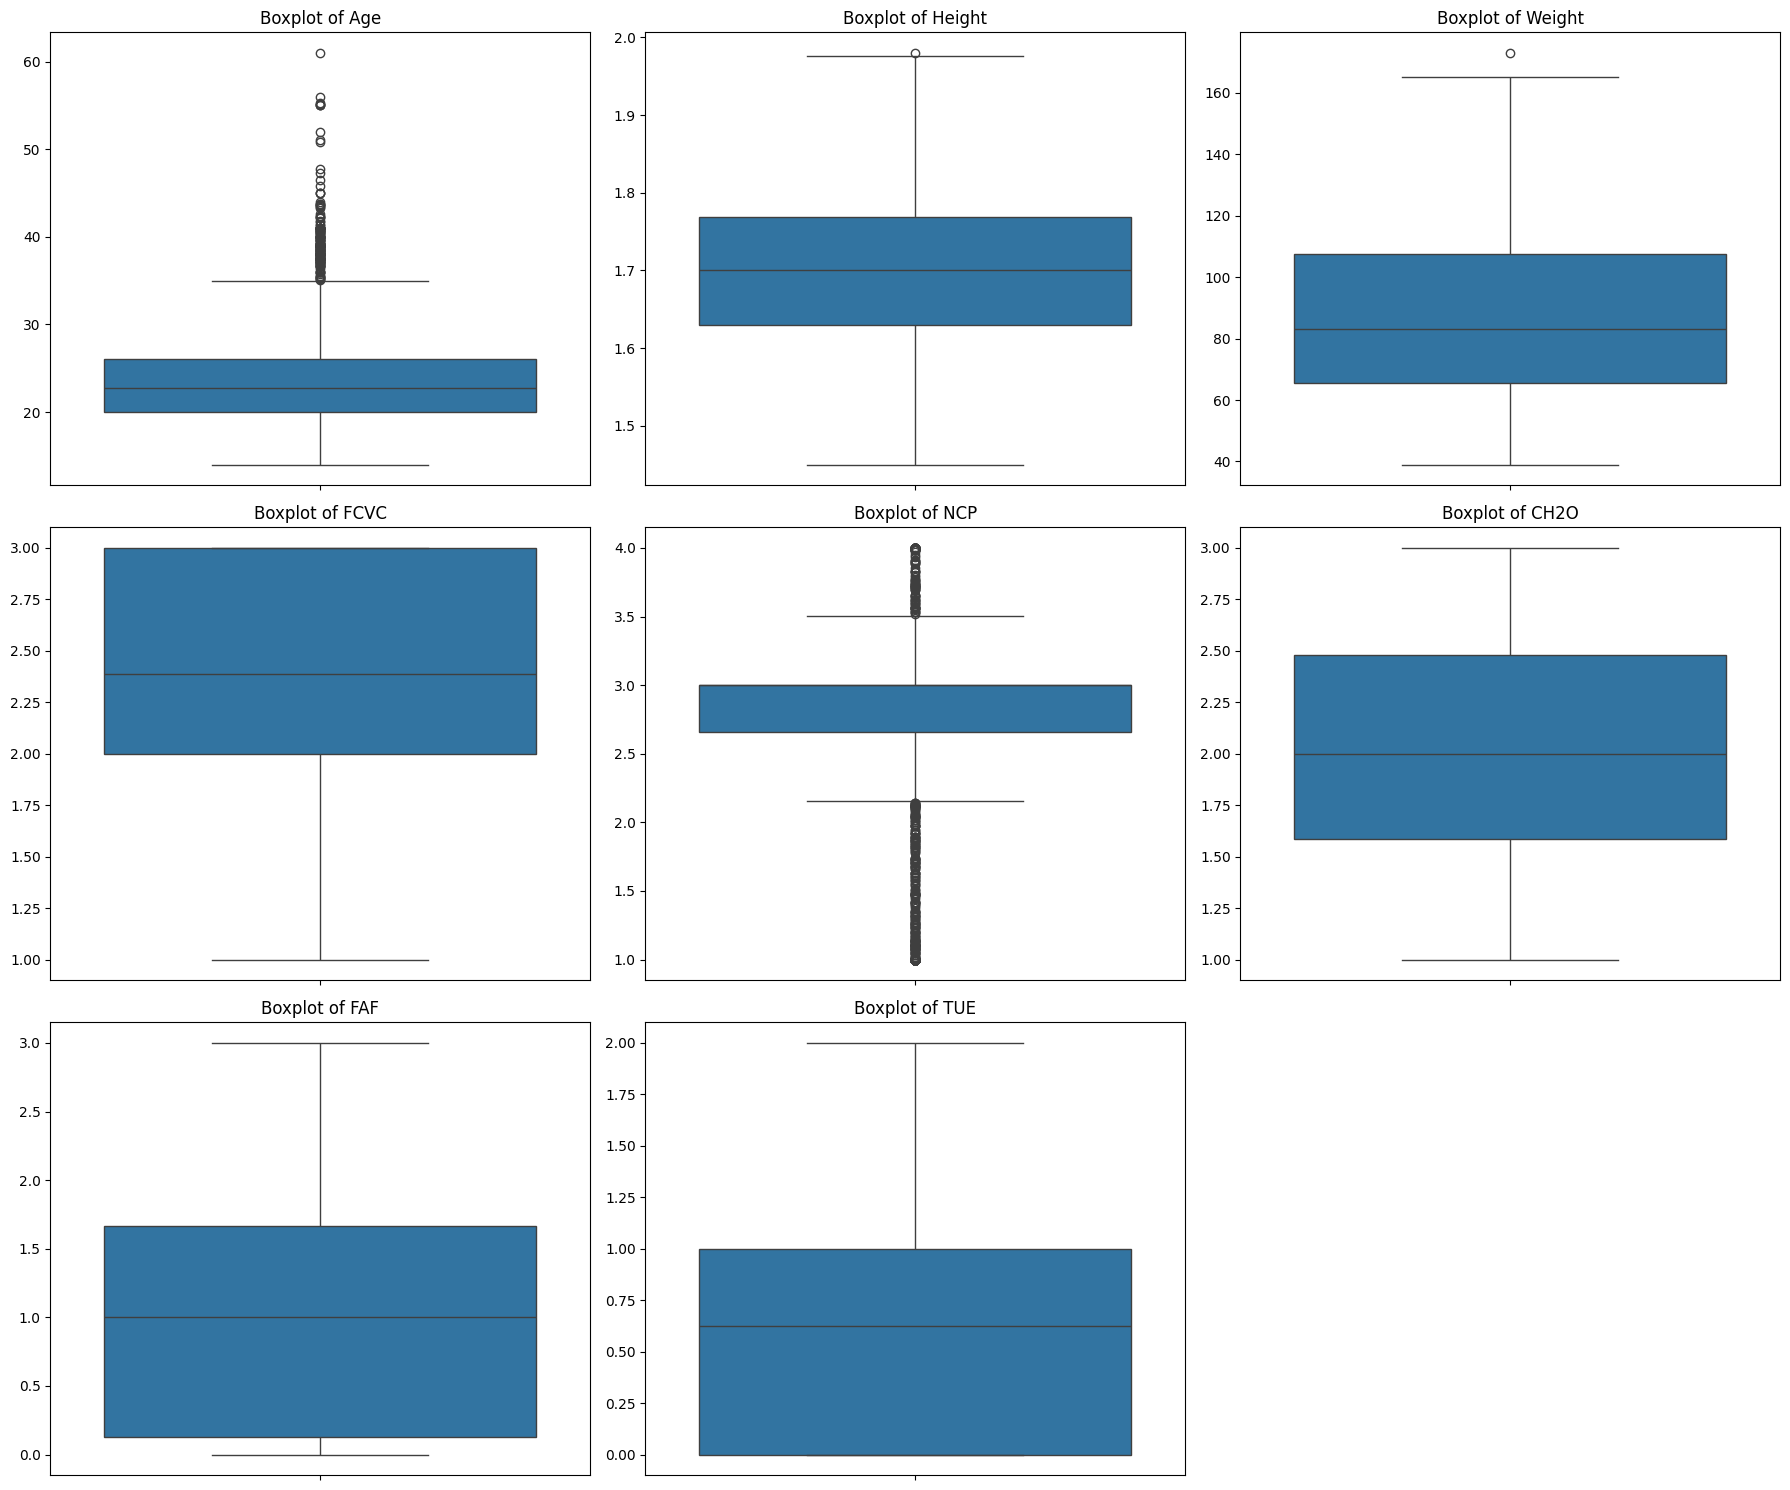

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Determine the number of rows and columns for subplots
num_cols = len(numerical_cols)
num_rows = (num_cols + 2) // 3  # Aim for 3 columns per row

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('') # Remove y-label to avoid clutter

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

*La muestra nos da una poblacion mas joven que el promedio de latinoamerica, la media muestral es de aproximadamente 22 años, mientras que el promedio es de +30 años

*Se sabe que la muestra se tomo por medio de una consulta web, siendo el promedio de edad para personas que usan internet de 32.5 años

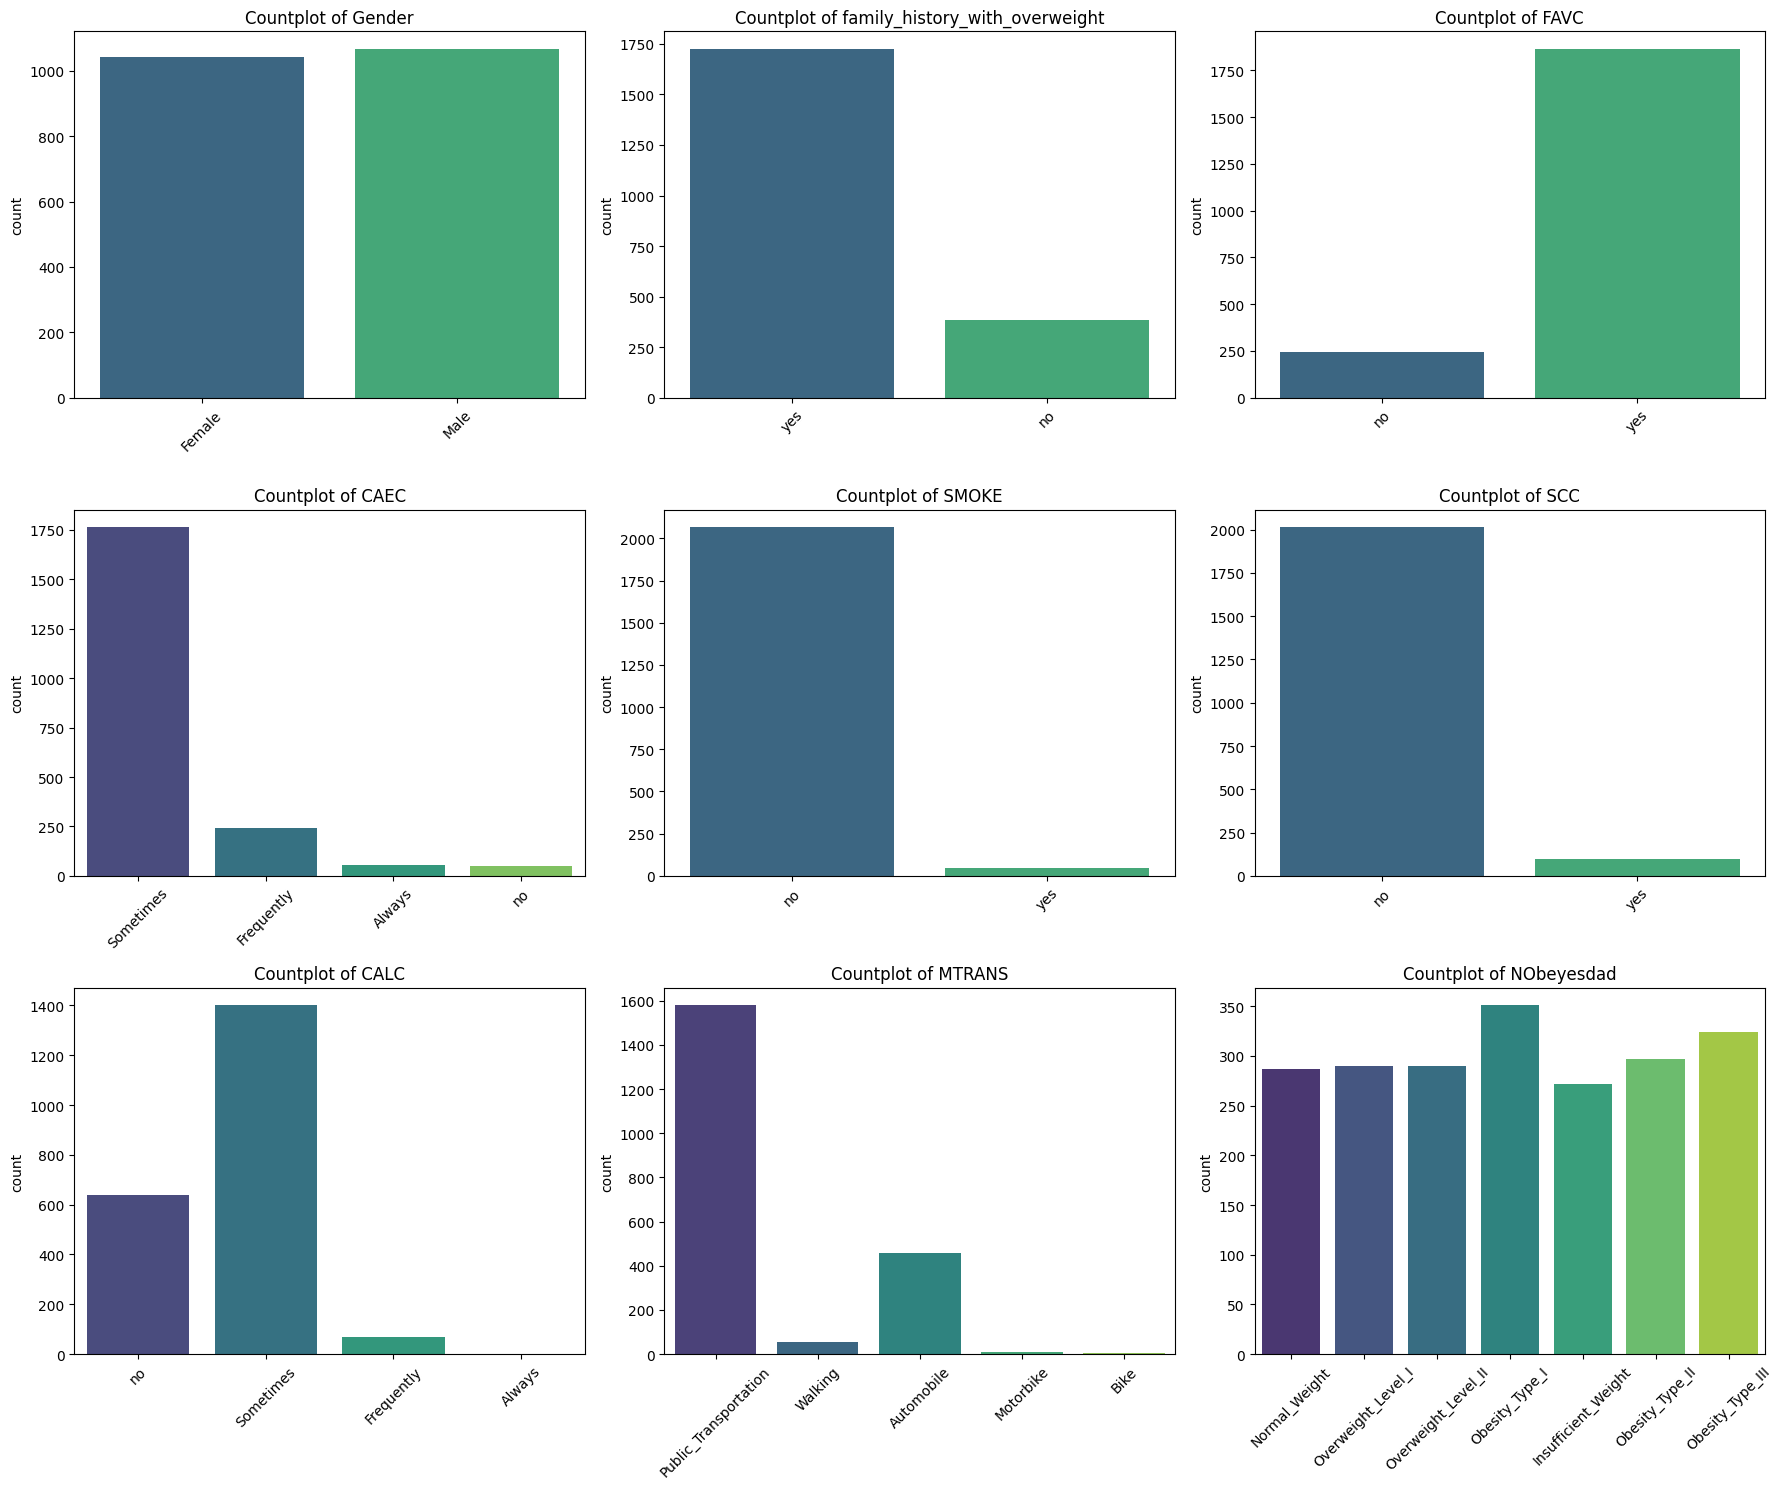

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify non-numerical (object type) columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Determine the number of rows and columns for subplots
num_categorical_cols = len(categorical_cols)
num_rows_cat = (num_categorical_cols + 2) // 3  # Aim for 3 columns per row

fig_cat, axes_cat = plt.subplots(num_rows_cat, 3, figsize=(18, num_rows_cat * 5))
axes_cat = axes_cat.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes_cat[i], palette='viridis', hue=df[col], legend=False)
    axes_cat[i].set_title(f'Countplot of {col}')
    axes_cat[i].set_xlabel('') # Remove x-label to avoid clutter
    axes_cat[i].tick_params(axis='x', rotation=45)

# Remove any unused subplots
for j in range(i + 1, len(axes_cat)):
    fig_cat.delaxes(axes_cat[j])

plt.tight_layout()
plt.show()

Se realiza one hot encoding para variables categoricas

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Create a copy of the dataframe to work on
df_encoded = df.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# Initialize OneHotEncoder for binary variables (dropping one category to avoid multicollinearity)
onehot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
# Initialize LabelEncoder for multi-class variables
label_encoder = LabelEncoder()

binary_cols = []
multiclass_cols = []

print("Categorical columns identified:")
for col in categorical_cols:
    num_unique = df_encoded[col].nunique()
    print(f"- {col}: {num_unique} unique values")
    if num_unique == 2:
        binary_cols.append(col)
    elif num_unique > 2:
        multiclass_cols.append(col)
    else:
        print(f"  Warning: Column {col} has less than 2 unique values and will be skipped.")

if binary_cols:
    print("\nApplying One-Hot Encoding to binary columns:")
    for col in binary_cols:
        print(f"  - Encoding {col}")
        # One-hot encode and create new columns
        encoded_data = onehot_encoder.fit_transform(df_encoded[[col]])
        # Get feature names for the new columns, adjusting for drop='first'
        feature_names = onehot_encoder.get_feature_names_out([col])
        # Create a DataFrame from the encoded data
        encoded_df = pd.DataFrame(encoded_data, columns=feature_names, index=df_encoded.index)
        # Concatenate with the main dataframe and drop original column
        df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
        df_encoded = df_encoded.drop(columns=[col])

if multiclass_cols:
    print("\nApplying Label Encoding to multi-class columns:")
    for col in multiclass_cols:
        print(f"  - Encoding {col}")
        df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

print("\nDataFrame after encoding (first 5 rows):")
print(df_encoded.head())
print("\nDataFrame info after encoding:")
print(df_encoded.info())

Categorical columns identified:
- Gender: 2 unique values
- family_history_with_overweight: 2 unique values
- FAVC: 2 unique values
- CAEC: 4 unique values
- SMOKE: 2 unique values
- SCC: 2 unique values
- CALC: 4 unique values
- MTRANS: 5 unique values
- NObeyesdad: 7 unique values

Applying One-Hot Encoding to binary columns:
  - Encoding Gender
  - Encoding family_history_with_overweight
  - Encoding FAVC
  - Encoding SMOKE
  - Encoding SCC

Applying Label Encoding to multi-class columns:
  - Encoding CAEC
  - Encoding CALC
  - Encoding MTRANS
  - Encoding NObeyesdad

DataFrame after encoding (first 5 rows):
    Age  Height  Weight  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  MTRANS  \
0  21.0    1.62    64.0   2.0  3.0     2   2.0  0.0  1.0     3       3   
1  21.0    1.52    56.0   3.0  3.0     2   3.0  3.0  0.0     2       3   
2  23.0    1.80    77.0   2.0  3.0     2   2.0  2.0  1.0     1       3   
3  27.0    1.80    87.0   3.0  3.0     2   2.0  2.0  0.0     1       4   
4  22.0    

##Correlaciones

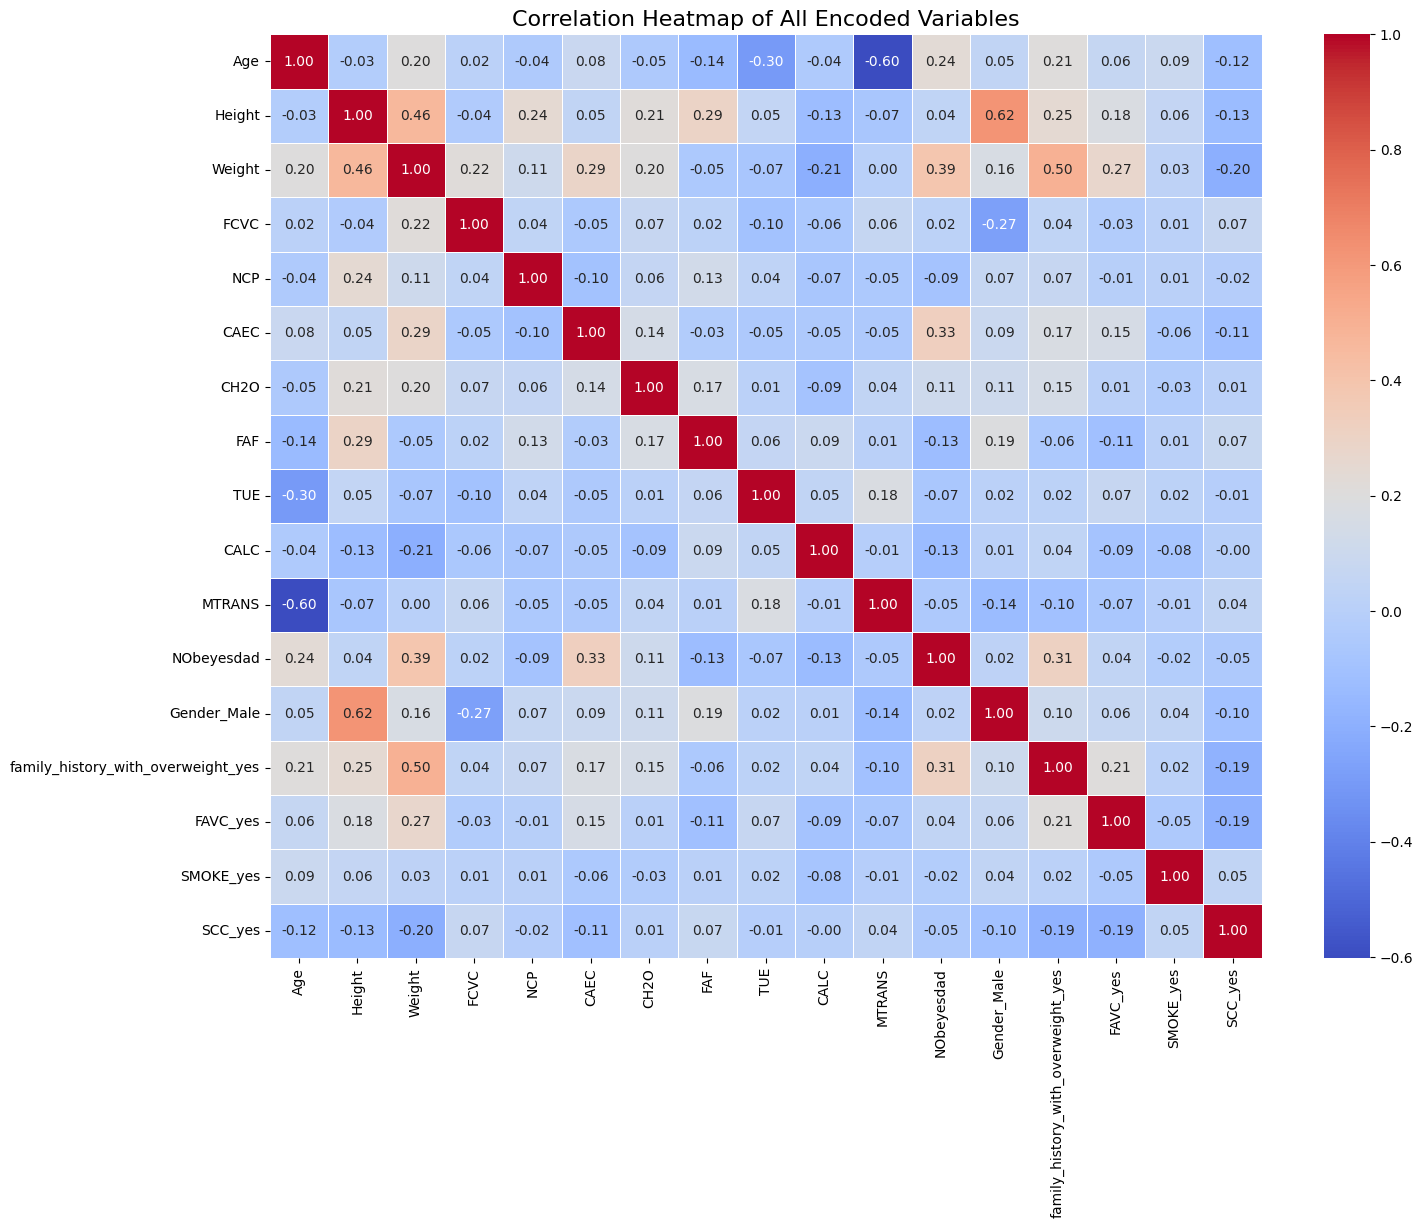

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('Correlation Heatmap of All Encoded Variables', fontsize=16)
plt.show()

##Clusters

In [ ]:
print(f"Shape of df_encoded before dropping 'NObeyesdad': {df_encoded.shape}")

# Drop the 'NObeyesdad' column
df_encoded = df_encoded.drop(columns=['NObeyesdad'])

print(f"Shape of df_encoded after dropping 'NObeyesdad': {df_encoded.shape}")
print("\nFirst 5 rows of df_encoded after dropping 'NObeyesdad':")
print(df_encoded.head())
print("\nInfo of df_encoded after dropping 'NObeyesdad':")
df_encoded.info()

Shape of df_encoded before dropping 'NObeyesdad': (2111, 17)
Shape of df_encoded after dropping 'NObeyesdad': (2111, 16)

First 5 rows of df_encoded after dropping 'NObeyesdad':
    Age  Height  Weight  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  MTRANS  \
0  21.0    1.62    64.0   2.0  3.0     2   2.0  0.0  1.0     3       3   
1  21.0    1.52    56.0   3.0  3.0     2   3.0  3.0  0.0     2       3   
2  23.0    1.80    77.0   2.0  3.0     2   2.0  2.0  1.0     1       3   
3  27.0    1.80    87.0   3.0  3.0     2   2.0  2.0  0.0     1       4   
4  22.0    1.78    89.8   2.0  1.0     2   2.0  0.0  0.0     2       3   

   Gender_Male  family_history_with_overweight_yes  FAVC_yes  SMOKE_yes  \
0          0.0                                 1.0       0.0        0.0   
1          0.0                                 1.0       0.0        1.0   
2          1.0                                 1.0       0.0        0.0   
3          1.0                                 0.0       0.0        0.0   
4 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

# Convert scaled data back to a DataFrame for easier inspection (optional)
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

# Apply KMeans clustering
# Let's start with 4 clusters as a reasonable initial guess.
# In a real scenario, you would use methods like the elbow method
# or silhouette score to find an optimal number of clusters.

k = 4 # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is important for robust results
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

print(f"Distribution of samples per cluster (k={k}):")
print(df_encoded['Cluster'].value_counts())

print("\nFirst 5 rows of df_encoded with new 'Cluster' column:")
print(df_encoded.head())

# Optional: Visualize the clusters (e.g., using PCA for dimensionality reduction if data is high-dimensional)
# For simplicity, let's try a pairplot of a few key features colored by cluster
# Note: This might be slow or hard to interpret for many features.
# Let's visualize with a pairplot of a few numerical features and the cluster.

# Select a few features for visualization, e.g., Age, Height, Weight
# selected_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'Cluster']
# if len(df_encoded.columns) > 6: # Avoid too many features in pairplot
#     sns.pairplot(df_encoded[selected_features], hue='Cluster', palette='viridis')
# else:
#     sns.pairplot(df_encoded, hue='Cluster', palette='viridis')
# plt.suptitle('Pairplot of selected features by Cluster', y=1.02)
# plt.show()


Distribution of samples per cluster (k=4):
Cluster
2    762
1    489
3    478
0    382
Name: count, dtype: int64

First 5 rows of df_encoded with new 'Cluster' column:
    Age  Height  Weight  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  MTRANS  \
0  21.0    1.62    64.0   2.0  3.0     2   2.0  0.0  1.0     3       3   
1  21.0    1.52    56.0   3.0  3.0     2   3.0  3.0  0.0     2       3   
2  23.0    1.80    77.0   2.0  3.0     2   2.0  2.0  1.0     1       3   
3  27.0    1.80    87.0   3.0  3.0     2   2.0  2.0  0.0     1       4   
4  22.0    1.78    89.8   2.0  1.0     2   2.0  0.0  0.0     2       3   

   Gender_Male  family_history_with_overweight_yes  FAVC_yes  SMOKE_yes  \
0          0.0                                 1.0       0.0        0.0   
1          0.0                                 1.0       0.0        1.0   
2          1.0                                 1.0       0.0        0.0   
3          1.0                                 0.0       0.0        0.0   
4          1

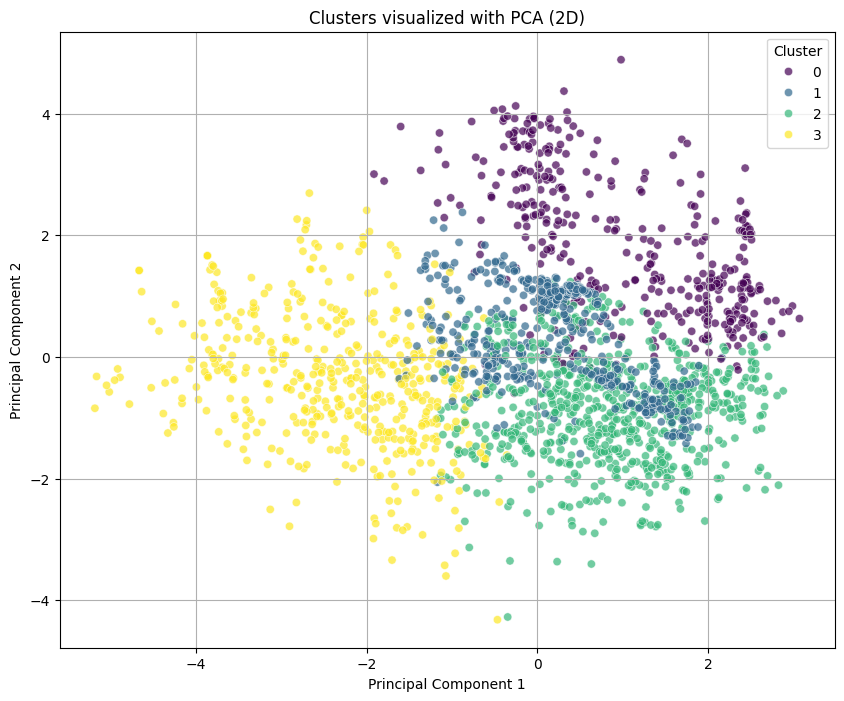

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled) # Use df_scaled for PCA

# Create a DataFrame for the PCA results with the Cluster column
df_pca_kmeans = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca_kmeans['Cluster'] = df_encoded['Cluster']

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    palette='viridis',
    data=df_pca_kmeans,
    legend='full',
    alpha=0.7
)
plt.title('Clusters visualized with PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

# Apply PCA to reduce dimensions to 3
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled) # Use df_scaled for PCA

# Create a DataFrame for the 3D PCA results with the Cluster column
df_pca_kmeans_3d = pd.DataFrame(
    data=df_pca_3d,
    columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3']
)
df_pca_kmeans_3d['Cluster'] = df_encoded['Cluster'].astype(str) # Convert to string for discrete colors in Plotly

# Visualize the clusters in 3D using Plotly
fig = px.scatter_3d(
    df_pca_kmeans_3d,
    x='Principal Component 1',
    y='Principal Component 2',
    z='Principal Component 3',
    color='Cluster',
    title='Clusters visualized with PCA (3D)',
    labels={
        'Principal Component 1': 'Principal Component 1',
        'Principal Component 2': 'Principal Component 2',
        'Principal Component 3': 'Principal Component 3'
    },
    height=700
)
fig.show()

##Elbow metod
Metodo del codo


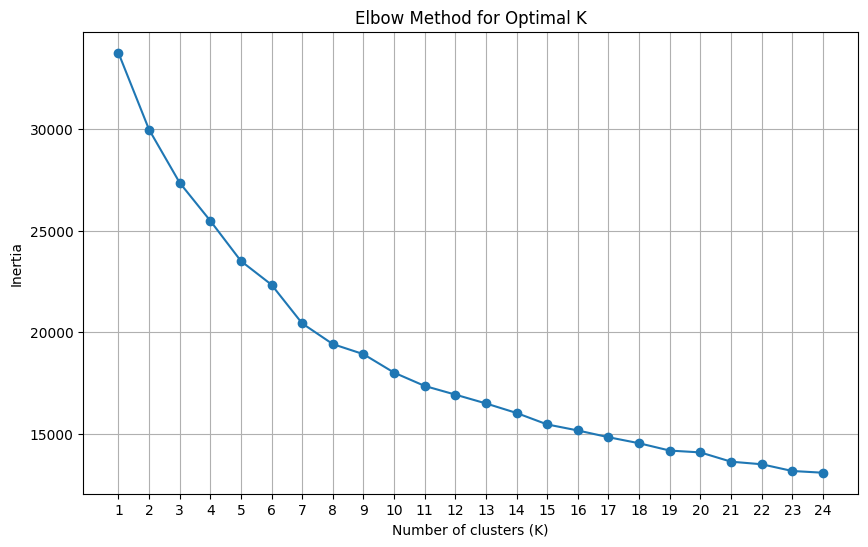

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# List to store the inertia values for each number of clusters
inertia = []

# Range of clusters to test (e.g., from 1 to 10)
k_range = range(1, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is important for robust results
    kmeans.fit(df_scaled) # Use the scaled data for clustering
    inertia.append(kmeans.inertia_)

# Plotting the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()


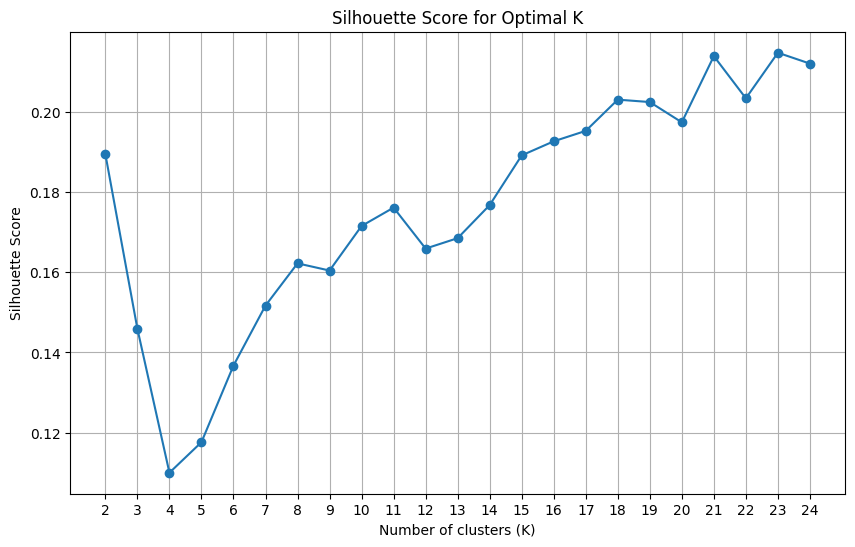

In [ ]:
from sklearn.metrics import silhouette_score

# List to store the silhouette scores for each number of clusters
silhouette_scores = []

# Range of clusters to test (silhouette score requires at least 2 clusters)
k_range_silhouette = range(2, 25) # Using the same upper bound as elbow method for consistency

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    # Calculate Silhouette Score
    score = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(score)

# Plotting the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()




*   Se probara con k =8 basado por el metodo del codo y silhoeutte
*   



In [ ]:

k = 8 # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is important for robust results
df_encoded['Cluster'] = kmeans.fit_predict(df_scaled)

print(f"Distribution of samples per cluster (k={k}):")
print(df_encoded['Cluster'].value_counts())

print("\nFirst 5 rows of df_encoded with new 'Cluster' column:")
print(df_encoded.head())

Distribution of samples per cluster (k=8):
Cluster
1    548
4    356
6    344
0    319
7    229
2    180
5     91
3     44
Name: count, dtype: int64

First 5 rows of df_encoded with new 'Cluster' column:
    Age  Height  Weight  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  MTRANS  \
0  21.0    1.62    64.0   2.0  3.0     2   2.0  0.0  1.0     3       3   
1  21.0    1.52    56.0   3.0  3.0     2   3.0  3.0  0.0     2       3   
2  23.0    1.80    77.0   2.0  3.0     2   2.0  2.0  1.0     1       3   
3  27.0    1.80    87.0   3.0  3.0     2   2.0  2.0  0.0     1       4   
4  22.0    1.78    89.8   2.0  1.0     2   2.0  0.0  0.0     2       3   

   Gender_Male  family_history_with_overweight_yes  FAVC_yes  SMOKE_yes  \
0          0.0                                 1.0       0.0        0.0   
1          0.0                                 1.0       0.0        1.0   
2          1.0                                 1.0       0.0        0.0   
3          1.0                                 0.0 

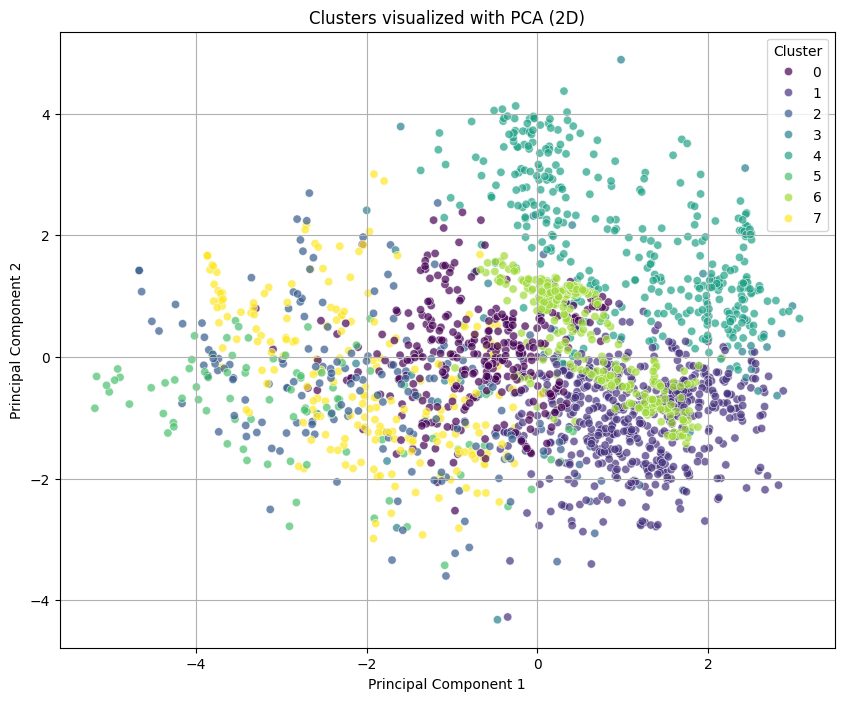

In [ ]:
# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled) # Use df_scaled for PCA

# Create a DataFrame for the PCA results with the Cluster column
df_pca_kmeans = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca_kmeans['Cluster'] = df_encoded['Cluster']

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    palette='viridis',
    data=df_pca_kmeans,
    legend='full',
    alpha=0.7
)
plt.title('Clusters visualized with PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:
# Apply PCA to reduce dimensions to 3
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled) # Use df_scaled for PCA

# Create a DataFrame for the 3D PCA results with the Cluster column
df_pca_kmeans_3d = pd.DataFrame(
    data=df_pca_3d,
    columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3']
)
df_pca_kmeans_3d['Cluster'] = df_encoded['Cluster'].astype(str) # Convert to string for discrete colors in Plotly

# Visualize the clusters in 3D using Plotly
fig = px.scatter_3d(
    df_pca_kmeans_3d,
    x='Principal Component 1',
    y='Principal Component 2',
    z='Principal Component 3',
    color='Cluster',
    title='Clusters visualized with PCA (3D)',
    labels={
        'Principal Component 1': 'Principal Component 1',
        'Principal Component 2': 'Principal Component 2',
        'Principal Component 3': 'Principal Component 3'
    },
    height=700
)
fig.show()

In [ ]:
# To interpret the clusters, let's examine the mean values of each feature for each cluster.
# This will help us understand the characteristics that define each cluster.
cluster_means = df_encoded.groupby('Cluster').mean()

print("Mean values of features per cluster:")
print(cluster_means)

# Optional: You might want to visualize these means for easier comparison
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(15, 8))
# sns.heatmap(cluster_means.T, annot=True, cmap='viridis', fmt=".2f")
# plt.title('Mean Feature Values Per Cluster')
# plt.xlabel('Cluster')
# plt.ylabel('Feature')
# plt.show()


Mean values of features per cluster:
               Age    Height      Weight      FCVC       NCP      CAEC  \
Cluster                                                                  
0        22.416353  1.656094   77.173561  2.334810  2.256469  1.727273   
1        22.308565  1.785604   92.416857  2.219906  2.905926  1.923358   
2        21.686683  1.648933   65.694781  2.376723  2.641281  1.683333   
3        28.312669  1.737161   91.206810  2.471433  2.727273  1.681818   
4        34.446325  1.703146   91.536710  2.337162  2.617384  1.943820   
5        20.467392  1.643994   61.900903  2.594475  2.631595  1.615385   
6        23.342754  1.686335  117.891633  2.963492  3.003021  2.011628   
7        20.276401  1.642664   56.364333  2.275834  2.433914  1.799127   

             CH2O       FAF       TUE      CALC    MTRANS  Gender_Male  \
Cluster                                                                  
0        1.814121  0.940875  0.845436  2.724138  2.990596     0.282132   


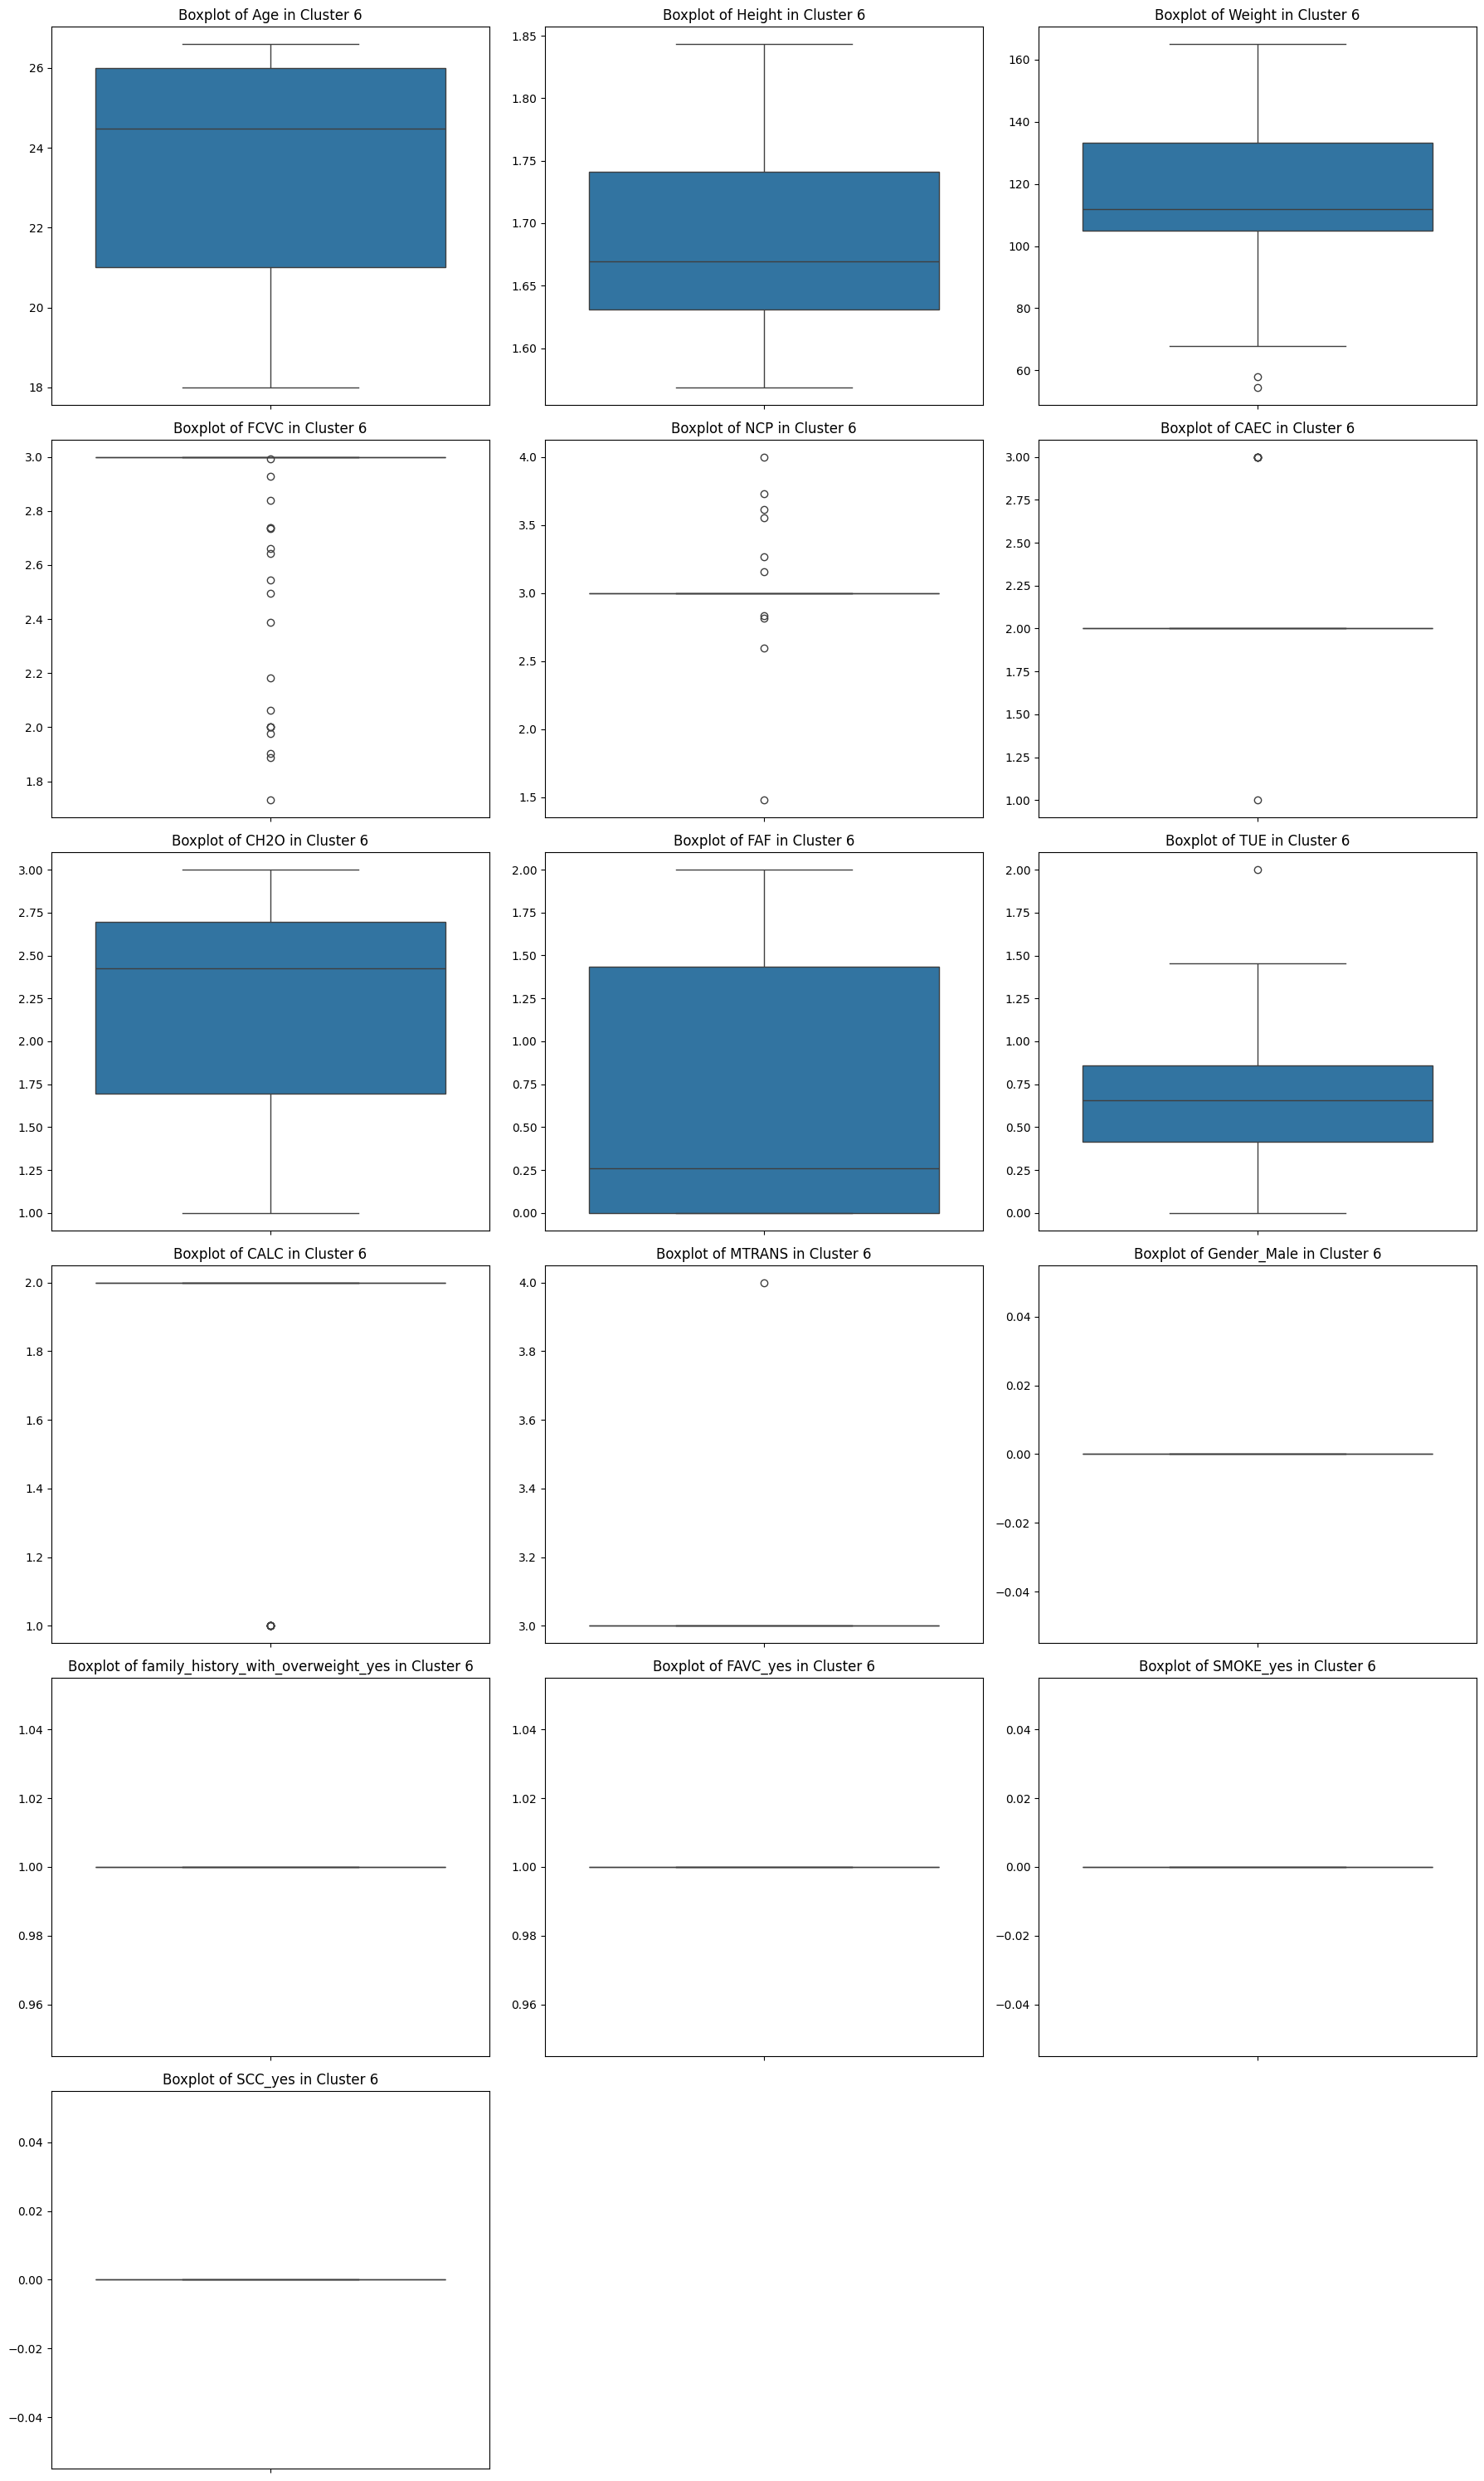

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter df_encoded for Cluster 6
df_cluster_6 = df_encoded[df_encoded['Cluster'] == 6]

# Identify numerical columns in the original dataframe (excluding 'Cluster' itself for plotting)
# We'll re-identify them from the filtered dataframe, but ensure 'Cluster' is not included if it's numerical
numerical_cols_cluster_6 = df_cluster_6.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Remove 'Cluster' column from numerical_cols_cluster_6 if it was included
if 'Cluster' in numerical_cols_cluster_6:
    numerical_cols_cluster_6.remove('Cluster')

# Determine the number of rows and columns for subplots
num_cols_6 = len(numerical_cols_cluster_6)
num_rows_6 = (num_cols_6 + 2) // 3  # Aim for 3 columns per row

fig_6, axes_6 = plt.subplots(num_rows_6, 3, figsize=(18, num_rows_6 * 5))
axes_6 = axes_6.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols_cluster_6):
    sns.boxplot(y=df_cluster_6[col], ax=axes_6[i])
    axes_6[i].set_title(f'Boxplot of {col} in Cluster 6')
    axes_6[i].set_ylabel('') # Remove y-label to avoid clutter

# Remove any unused subplots
for j in range(i + 1, len(axes_6)):
    fig_6.delaxes(axes_6[j])

plt.tight_layout()
plt.show()


--- Descriptive Statistics for Cluster 6 (Numerical Features) ---
              Age      Height      Weight        FCVC         NCP        CH2O  \
count  344.000000  344.000000  344.000000  344.000000  344.000000  344.000000   
mean    23.342754    1.686335  117.891633    2.963492    3.003021    2.220383   
std      2.823270    0.063376   18.648119    0.175056    0.118879    0.596903   
min     18.000000    1.568543   54.500000    1.729824    1.478334    1.000000   
25%     21.001477    1.630878  105.051063    3.000000    3.000000    1.694937   
50%     24.486308    1.669196  111.936412    3.000000    3.000000    2.426011   
75%     26.000000    1.741059  133.351254    3.000000    3.000000    2.696239   
max     26.595893    1.843419  165.057269    3.000000    4.000000    3.000000   

              FAF         TUE  
count  344.000000  344.000000  
mean     0.667691    0.612003  
std      0.716327    0.295536  
min      0.000000    0.000000  
25%      0.000000    0.413382  
50%      0.2

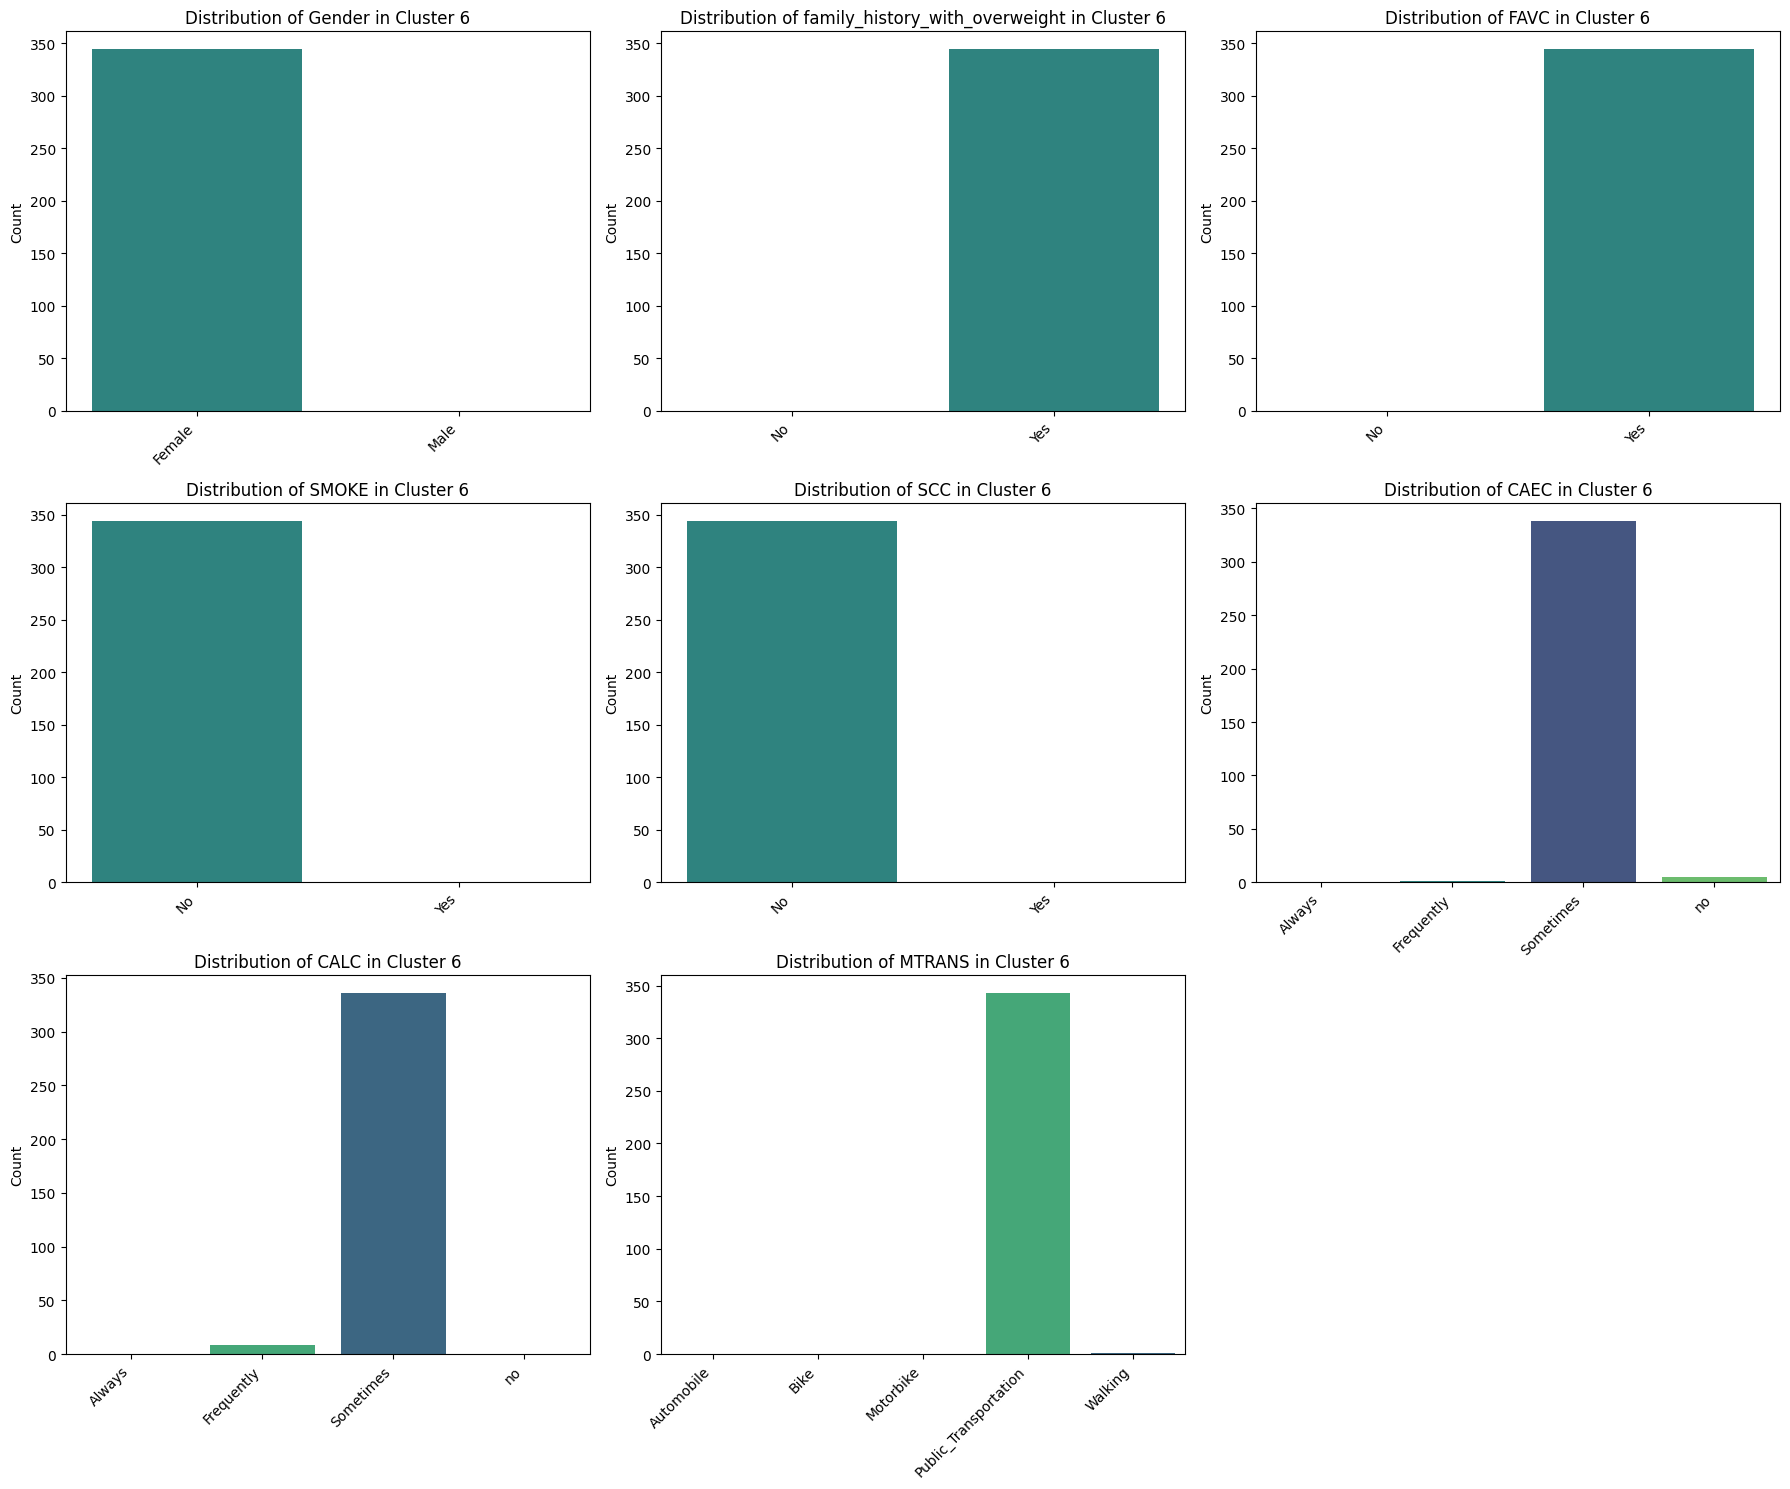


--- Interpretation Guide for Cluster 6 ---
Cluster 6 consists of 344 individuals. To describe this cluster:
- **Numerical Characteristics**: Review the 'Descriptive Statistics' table above for columns like 'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', and 'TUE'. Pay attention to the mean, standard deviation, min, and max values to understand the central tendency and spread of these features within Cluster 6.
- **Categorical Characteristics**: Examine the 'Distributions for Cluster 6 (Categorical Features)' count plots. Each plot shows the frequency of different categories within this cluster for features like Gender, family history, eating habits (FAVC, CAEC, CALC, SCC), smoking habits (SMOKE), transportation (MTRANS), and their NObeyesdad (Obesity level).
  - For example, if 'FAVC_yes' (Frequent consumption of high caloric food) shows a high bar for 'Yes', it means this cluster tends to consume high-caloric food frequently.
  - If 'NObeyesdad' shows 'Obesity_Type_III' as t

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume df_encoded and df_cluster_6 are available from previous steps.
# Filter the DataFrame for Cluster 6 (re-defining it here for self-containment if needed)
df_cluster_6 = df_encoded[df_encoded['Cluster'] == 6]

# 1. Descriptive Statistics for numerical features in Cluster 6
print("--- Descriptive Statistics for Cluster 6 (Numerical Features) ---")
# List of original numerical columns
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
print(df_cluster_6[numerical_cols].describe())

# Define mappings for label-encoded columns to make plots interpretable
caec_map = {0: 'Always', 1: 'Frequently', 2: 'Sometimes', 3: 'no'}
calc_map = {0: 'Always', 1: 'Frequently', 2: 'Sometimes', 3: 'no'}
mtrans_map = {0: 'Automobile', 1: 'Bike', 2: 'Motorbike', 3: 'Public_Transportation', 4: 'Walking'}
# nobeyesdad_map is defined but not used for plotting as the column was dropped.
nobeyesdad_map = {0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}

# 2. Distributions for categorical (encoded) features in Cluster 6
print("\n--- Distributions for Cluster 6 (Categorical Features) ---")

# Binary encoded columns and their labels
binary_cols = ['Gender_Male', 'family_history_with_overweight_yes', 'FAVC_yes', 'SMOKE_yes', 'SCC_yes']
binary_labels = {
    'Gender_Male': {0: 'Female', 1: 'Male'},
    'family_history_with_overweight_yes': {0: 'No', 1: 'Yes'},
    'FAVC_yes': {0: 'No', 1: 'Yes'},
    'SMOKE_yes': {0: 'No', 1: 'Yes'},
    'SCC_yes': {0: 'No', 1: 'Yes'}
}

# Label encoded columns and their maps
# 'NObeyesdad' is removed from this list as it was dropped from df_encoded
label_encoded_cols = ['CAEC', 'CALC', 'MTRANS']
label_encoded_maps = {
    'CAEC': caec_map,
    'CALC': calc_map,
    'MTRANS': mtrans_map
}

# Combine all categorical columns for plotting
all_categorical_cols = binary_cols + label_encoded_cols
num_cat_cols = len(all_categorical_cols)
num_rows_cat = (num_cat_cols + 2) // 3 # Aim for 3 columns per row
num_cols_cat = 3

plt.figure(figsize=(num_cols_cat * 6, num_rows_cat * 5))

for i, col in enumerate(all_categorical_cols):
    plt.subplot(num_rows_cat, num_cols_cat, i + 1)

    if col in binary_cols:
        # For binary columns, map 0/1 to meaningful labels
        plot_data = df_cluster_6[col].map(binary_labels[col])
        # Ensure consistent order for binary plots
        order_labels = [label_val for key, label_val in sorted(binary_labels[col].items())]
        sns.countplot(x=plot_data, hue=plot_data, palette='viridis', order=order_labels, legend=False)
        plt.title(f'Distribution of {col.replace("_yes", "").replace("_Male", "")} in Cluster 6') # Clean up title
    elif col in label_encoded_cols:
        # For label encoded columns, map to original categories
        plot_data = df_cluster_6[col].map(label_encoded_maps[col])
        # Ensure consistent order for label encoded plots
        order_labels = [label_val for key, label_val in sorted(label_encoded_maps[col].items())]
        sns.countplot(x=plot_data, hue=plot_data, palette='viridis', order=order_labels, legend=False)
        plt.title(f'Distribution of {col} in Cluster 6')

    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    plt.xlabel('') # Clear x-label as title is descriptive
    plt.tight_layout()

plt.show()

print(f"\n--- Interpretation Guide for Cluster 6 ---")
print(f"Cluster 6 consists of {len(df_cluster_6)} individuals. To describe this cluster:")
print(f"- **Numerical Characteristics**: Review the 'Descriptive Statistics' table above for columns like 'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', and 'TUE'. Pay attention to the mean, standard deviation, min, and max values to understand the central tendency and spread of these features within Cluster 6.")
print(f"- **Categorical Characteristics**: Examine the 'Distributions for Cluster 6 (Categorical Features)' count plots. Each plot shows the frequency of different categories within this cluster for features like Gender, family history, eating habits (FAVC, CAEC, CALC, SCC), smoking habits (SMOKE), transportation (MTRANS), and their NObeyesdad (Obesity level).")
print(f"  - For example, if 'FAVC_yes' (Frequent consumption of high caloric food) shows a high bar for 'Yes', it means this cluster tends to consume high-caloric food frequently.")
print(f"  - If 'NObeyesdad' shows 'Obesity_Type_III' as the most frequent category, it indicates that individuals in Cluster 6 predominantly fall into that obesity level.")
print(f"  By analyzing these distributions, you can build a detailed profile for Cluster 6.")

##PCA

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

# Assuming df_scaled is already available from previous steps

# Initialize PCA with 3 components
pca_3_components = PCA(n_components=3)

# Fit PCA on the scaled data
pca_3_components.fit(df_scaled)

# Get the principal components (loadings)
# The 'components_' attribute shows how each original feature contributes to each principal component
principal_components_df = pd.DataFrame(
    pca_3_components.components_,
    columns=df_scaled.columns,
    index=[f'Principal Component {i+1}' for i in range(pca_3_components.n_components)]
)

print("Linear Combination of Variables for Each Principal Component:")
print(principal_components_df)

Linear Combination of Variables for Each Principal Component:
                            Age    Height    Weight      FCVC       NCP  \
Principal Component 1  0.214286  0.448928  0.469304 -0.000416  0.135005   
Principal Component 2  0.536813 -0.331823  0.040168  0.080329 -0.192239   
Principal Component 3 -0.264036 -0.170945  0.316540  0.369233 -0.091056   

                           CAEC      CH2O       FAF       TUE      CALC  \
Principal Component 1  0.225261  0.202924  0.064880 -0.047612 -0.128607   
Principal Component 2  0.101928 -0.201730 -0.381969 -0.336565 -0.018699   
Principal Component 3  0.189640  0.129999 -0.270356  0.124490 -0.185884   

                         MTRANS  Gender_Male  \
Principal Component 1 -0.178916     0.330461   
Principal Component 2 -0.397054    -0.253151   
Principal Component 3  0.453372    -0.412278   

                       family_history_with_overweight_yes  FAVC_yes  \
Principal Component 1                            0.376399  0.256077   
P

In [ ]:
# Apply PCA to reduce dimensions to 3
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled) # Use df_scaled for PCA

# Create a DataFrame for the 3D PCA results with the Cluster column
df_pca_kmeans_3d = pd.DataFrame(
    data=df_pca_3d,
    columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3']
)
df_pca_kmeans_3d['Cluster'] = df_encoded['Cluster'].astype(str) # Convert to string for discrete colors in Plotly

# Visualize the clusters in 3D using Plotly
fig = px.scatter_3d(
    df_pca_kmeans_3d,
    x='Principal Component 1',
    y='Principal Component 2',
    z='Principal Component 3',
    color='Cluster',
    title='Clusters visualized with PCA (3D)',
    labels={
        'Principal Component 1': 'Principal Component 1',
        'Principal Component 2': 'Principal Component 2',
        'Principal Component 3': 'Principal Component 3'
    },
    height=700
)
fig.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.express as px
import pandas as pd

# Assuming df_scaled is available

# 1. Apply PCA to reduce dimensions to 3
pca_for_clustering = PCA(n_components=3)
df_pca_components = pca_for_clustering.fit_transform(df_scaled)

# 2. Apply K-Means clustering on the 3 PCA components with 4 clusters
k_clusters = 4
kmeans_pca = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(df_pca_components)

# 3. Create a DataFrame for the 3D PCA results with the new Cluster column
df_pca_kmeans_3d_new = pd.DataFrame(
    data=df_pca_components,
    columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3']
)
df_pca_kmeans_3d_new['Cluster'] = cluster_labels_pca.astype(str) # Convert to string for discrete colors in Plotly

print(f"Distribution of samples per new PCA-based cluster (k={k_clusters}):")
print(df_pca_kmeans_3d_new['Cluster'].value_counts())

# 4. Visualize the clusters in 3D using Plotly
fig = px.scatter_3d(
    df_pca_kmeans_3d_new,
    x='Principal Component 1',
    y='Principal Component 2',
    z='Principal Component 3',
    color='Cluster',
    title=f'Clusters ({k_clusters} based on 3 PCA Components) visualized in 3D',
    labels={
        'Principal Component 1': 'Physical Attributes & Family History of Overweight',
        'Principal Component 2': 'Age & Lifestyle (Physical Activity/Technology/Transportation)',
        'Principal Component 3': 'Transportation & Eating Habits (Vegetable Consumption vs. High Caloric Food)'
    },
    height=700
)
fig.show()

Distribution of samples per new PCA-based cluster (k=4):
Cluster
1    684
2    565
0    487
3    375
Name: count, dtype: int64
